# NYC Taxi Trip Duration — Data Mining Project

This notebook covers the full data mining pipeline for the NYC Taxi Trip Duration dataset, including:
1. **Data Loading & Exploration** — Initial inspection of the raw dataset
2. **Data Preprocessing & Feature Engineering** — Outlier removal, trip classification, and derived features
3. **Weather Data Integration** — Merging external weather data with the trip dataset
4. **Regression (XGBoost)** — Predicting log-transformed trip duration
5. **Clustering (DBSCAN & KMeans)** — Spatial clustering of pickup locations

---

## Data Loading & Exploration

Load the training dataset and perform an initial inspection of its structure, data types, and basic statistics.

In [117]:
import pandas as pd

df = pd.read_csv("train.csv")

df.head()
df.tail()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


## Data Preprocessing & Feature Engineering

### Outlier Removal — Trip Duration

Inspect the `trip_duration` distribution and remove extreme outliers. Trips longer than **4 hours (14,400 seconds)** are considered anomalies and are dropped.

In [118]:
df['trip_duration'].describe()
df['trip_duration'].value_counts()

df = df[(df['trip_duration'] < 14400)]
df['trip_duration'].value_counts()

trip_duration
368      1624
408      1584
348      1582
367      1581
358      1577
         ... 
5300        1
6378        1
5508        1
4521        1
10632       1
Name: count, Length: 6089, dtype: int64

### Haversine Distance & Trip Type Classification

Compute the **Haversine (great-circle) distance** in kilometres between pickup and dropoff coordinates. This is then used to classify each trip into one of four categories:

| Trip Type | Condition |
|---|---|
| `cancellation` | 0 passengers, distance ≤ 0.2 km |
| `idle` | 0 passengers, distance > 0.2 km |
| `round_trip` | ≥ 1 passenger, distance ≤ 0.2 km |
| `normal` | all other trips |

In [119]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine(
    df['pickup_latitude'],
    df['pickup_longitude'],
    df['dropoff_latitude'],
    df['dropoff_longitude']
)

df['trip_type'] = 'normal'

df.loc[(df['passenger_count'] == 0) & (df['distance_km'] <= 0.2), 'trip_type'] = 'cancellation'
df.loc[(df['passenger_count'] == 0) & (df['distance_km'] > 0.2), 'trip_type'] = 'idle'
df.loc[(df['passenger_count'] > 0) & (df['distance_km']  <= 0.2), 'trip_type'] = 'round_trip'
df['trip_type'].value_counts()

df.to_csv("train2.csv", index = False)

### 2.3 Geographic Bounding Box Filter

Restrict coordinates to the **New York City area** to remove GPS errors and trips that started or ended outside the city.

In [120]:
LAT_MIN = 40.6
LAT_MAX = 40.9
LON_MIN = -74.1
LON_MAX = -73.6

df = df[
    (df['pickup_latitude'].between(LAT_MIN, LAT_MAX)) &
    (df['dropoff_latitude'].between(LAT_MIN, LAT_MAX)) &
    (df['pickup_longitude'].between(LON_MIN, LON_MAX)) &
    (df['dropoff_longitude'].between(LON_MIN, LON_MAX))
]

df.to_csv('train2.csv')

## Weather Data Integration (Optional)

The following cells merge an external weather dataset (`weather.csv`) with the taxi trip data. Weather features (average temperature, precipitation, snowfall) were investigated for correlation with trip duration.

> **Note:** These cells are intentionally commented out. Weather features were explored but ultimately **not used** for clustering or regression, as correlation analysis showed minimal impact on trip duration prediction.

In [121]:
import pandas as pd

df = pd.read_csv("train2.csv")      #original dataset (NO weather)
weather = pd.read_csv("weather.csv")


# FIX DATETIME FORMATS


# Convert pickup datetime (has time)
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')

# Extract ONLY date for merging
df['date'] = df['pickup_datetime'].dt.date


# Convert weather date (format: DD-MM-YYYY)
weather['date'] = pd.to_datetime(
    weather['date'],
    format="%d-%m-%Y",
    errors='coerce'
).dt.date


# Handle 'T' (trace snowfall)
weather['snow_fall'] = weather['snow_fall'].replace('T', 0.01)

# Convert all weather columns to numeric
weather_cols = [
    'maximum_temperature',
    'minimum_temperature',
    'average_temperature',
    'precipitation',
    'snow_fall',
    'snow_depth'
]

for col in weather_cols:
    weather[col] = pd.to_numeric(weather[col], errors='coerce')




df_merged = df.merge(weather, on='date', how='left')

# FEATURE ENGINEERING

df_merged['is_raining'] = (df_merged['precipitation'] > 0).astype(int)
df_merged['is_snowing'] = (df_merged['snow_fall'] > 0).astype(int)



# CLEANUP


# Drop helper column
df_merged.drop(columns=['date'], inplace=True)



# SAVE FINAL DATASET


df_merged.to_csv("train2_with_weather.csv", index=False)

print("Integration complete. File saved as train2_with_weather.csv")

Integration complete. File saved as train2_with_weather.csv


<h1> Classification</h1>

Data Preprocessing and Model Development

Reload the dataset and prepare it for classification by applying necessary preprocessing and model-building steps:

**Data cleaning:** Inconsistent and non-numeric values are handled, and missing entries are processed to ensure data quality.

**Feature transformation:** Categorical and non-numeric features are converted into suitable numerical formats for model compatibility.

**Feature selection:** Relevant input features are chosen to improve model efficiency and reduce noise.

**Dataset splitting:** The data is divided into training and testing sets to enable proper model evaluation.

**Feature scaling:** Standardization is applied where required to normalize feature distributions.

**Model training:** A Random Forest Classifier is trained on the processed dataset to perform classification.

**Hyperparameter tuning:** GridSearchCV is used to identify optimal model parameters and enhance performance.

In [122]:
#   Imports
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

print("All libraries imported successfully.")

All libraries imported successfully.


In [123]:
#   Removal of zero distance and zero duration trips for feature engineering
df = pd.read_csv("train2_with_weather.csv")


In [124]:
print(f"Before cleaning: {df.shape[0]} rows")

df = df[df['trip_duration'] > 0]
df = df[df['distance_km']   > 0]
df = df[df['trip_type']    != 'idle']   # Idle trips skew demand signals
df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)]

# Drop top 1% of trip durations as extreme outliers
df = df[df['trip_duration'] < df['trip_duration'].quantile(0.99)]

print(f"After cleaning:  {df.shape[0]} rows")

Before cleaning: 1451027 rows
After cleaning:  1430869 rows


In [125]:
#   Feature Engineering

# --- Datetime features ---
df['pickup_datetime']  = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

df['hour']        = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)
df['is_peak_hour'] = df['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

# --- Log-transform target---
df['log_trip_duration'] = np.log1p(df['trip_duration'])

# --- Encode store_and_fwd_flag ---
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'N': 0, 'Y': 1})

# --- Spatial features ---
df['manhattan_dist'] = (
    abs(df['pickup_latitude']  - df['dropoff_latitude']) +
    abs(df['pickup_longitude'] - df['dropoff_longitude'])
)
df['dist_hour'] = df['distance_km'] * df['hour']   # Distance × time interaction

# Coarse grid cell for pickup location (0.1-degree ≈ ~8 km)
df['pickup_grid'] = (
    df['pickup_latitude'].round(1).astype(str) + "_" +
    df['pickup_longitude'].round(1).astype(str)
)

# Fine-grained lat/lon bins (50 equal-width bins across NYC)
df['lat_bin'] = pd.cut(df['pickup_latitude'],  bins=50, labels=False)
df['lon_bin'] = pd.cut(df['pickup_longitude'], bins=50, labels=False)

print("Trip-level features added. Columns now:")
print(df.columns.tolist())

Trip-level features added. Columns now:
['Unnamed: 0', 'id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration', 'distance_km', 'trip_type', 'maximum_temperature', 'minimum_temperature', 'average_temperature', 'precipitation', 'snow_fall', 'snow_depth', 'is_raining', 'is_snowing', 'hour', 'day_of_week', 'is_weekend', 'is_peak_hour', 'log_trip_duration', 'manhattan_dist', 'dist_hour', 'pickup_grid', 'lat_bin', 'lon_bin']


In [126]:
# Loading and merging the weather dataset with the taxi dataset
df_weather = pd.read_csv("weather.csv")

# Parse dates (Day-Month-Year format)
df_weather['date'] = pd.to_datetime(df_weather['date'], format='%d-%m-%Y').dt.date

# Extract date key from taxi data
df['date'] = df['pickup_datetime'].dt.date

# Weather × peak-hour interaction features
df['rain_peak'] = df['precipitation'] * df['is_peak_hour']
df['snow_peak'] = df['snow_fall'] * df['is_peak_hour']

print(f"Integrated dataset shape: {df.shape}")
df[['date', 'pickup_datetime', 'average_temperature', 'precipitation', 'rain_peak']].head()

Integrated dataset shape: (1430869, 35)


,date,pickup_datetime,average_temperature,precipitation,rain_peak
0,2016-03-14,2016-03-14 17:24:55,45.5,0.29,0.29
1,2016-06-12,2016-06-12 00:43:35,72.5,0.00,0.00
2,2016-01-19,2016-01-19 11:35:24,22.0,0.00,0.00
3,2016-04-06,2016-04-06 19:32:31,39.0,0.00,0.00
4,2016-03-26,2016-03-26 13:30:55,46.5,0.00,0.00


In [127]:
# Aggregate to demand dataset as demand buckets
agg_cols = ['pickup_grid', 'hour', 'day_of_week', 'is_peak_hour']

# Count trips per bucket
counts = df.groupby(agg_cols).size().reset_index(name='trip_count')

cols = ['average_temperature', 'precipitation', 'snow_fall', 'rain_peak', 'snow_peak']

df[cols] = df[cols].replace('T', 0.01)   # optional, if needed
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# Average weather conditions per bucket
weather_agg = df.groupby(agg_cols).agg({
    'average_temperature': 'mean',
    'precipitation':       'mean',
    'snow_fall':           'mean',
    'rain_peak':           'mean',
    'snow_peak':           'mean'
}).reset_index()

demand_df = counts.merge(weather_agg, on=agg_cols)

print(f"Aggregated demand dataset shape: {demand_df.shape}")
demand_df.head()

Aggregated demand dataset shape: (1619, 10)


,pickup_grid,hour,day_of_week,is_peak_hour,trip_count,average_temperature,precipitation,snow_fall,rain_peak,snow_peak
0,40.6_-73.6,18,2,1,1,74.500000,0.00000,0.000000,0.0,0.0
1,40.6_-73.7,0,2,0,1,73.500000,0.00000,0.000000,0.0,0.0
2,40.6_-73.7,2,6,0,1,40.500000,0.00000,0.000000,0.0,0.0
3,40.6_-73.7,15,3,0,1,31.500000,0.00000,0.000000,0.0,0.0
4,40.6_-73.8,0,0,0,258,53.532946,0.15192,0.058953,0.0,0.0


In [128]:
# If >=20 trips in a bucket, demand = high
def label(x):
    return "High" if x >= 20 else "Normal"

demand_df['demand_class'] = demand_df['trip_count'].apply(label)

print("Target distribution:")
print(demand_df['demand_class'].value_counts(normalize=True) * 100)

Target distribution:
demand_class
High      50.710315
Normal    49.289685
Name: proportion, dtype: float64


In [129]:
# Preprocessing and train/ test split
# Cyclical features (hour, day_of_week) are treated as categorical and one-hot encoded
# We use a chronological (shuffle=False) split and TimeSeriesSplit cross-validation to prevent data leakage.

# Cast cyclical columns to string → treated as categorical
for col in ['hour', 'day_of_week']:
    demand_df[col] = demand_df[col].astype(str)

X = demand_df.drop(columns=['trip_count', 'demand_class'])
y = demand_df['demand_class']

cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'string']).columns.tolist()

print(f"Numeric features  : {num_cols}")
print(f"Categorical features: {cat_cols}")

# Pipelines for each column type
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe,     num_cols),
    ('cat', categorical_pipe, cat_cols)
])

# Chronological split — no shuffle to preserve time order
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, shuffle=False
)

# Time-aware CV to use during grid search
cv = TimeSeriesSplit(n_splits=5)

print(f"\nTrain shape: {X_train.shape} | Test shape: {X_test.shape}")

Numeric features  : ['is_peak_hour', 'average_temperature', 'precipitation', 'snow_fall', 'rain_peak', 'snow_peak']
Categorical features: ['pickup_grid', 'hour', 'day_of_week']

Train shape: (1295, 9) | Test shape: (324, 9)


In [130]:
# Model training and evaluation using GridsearchCV
pipe_rf = Pipeline([
    ('prep',  preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

params_rf = {
    'model__n_estimators':    [100, 200],
    'model__max_depth':       [10, 20, None],
    'model__min_samples_split': [2, 5],
    'model__class_weight':    ['balanced']
}

print("Training Random Forest with GridSearchCV... this may take a moment.")
grid_rf = GridSearchCV(
    pipe_rf,
    params_rf,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

best_model = grid_rf.best_estimator_
print(f"\nBest params: {grid_rf.best_params_}")

# ---- Evaluation ----
pred = best_model.predict(X_test)

print("\n========== RANDOM FOREST PERFORMANCE ==========")
print(f"Accuracy : {accuracy_score(y_test, pred):.4f}")
print(f"Macro F1 : {f1_score(y_test, pred, average='macro'):.4f}")

print("\nConfusion Matrix:")
labels = ['Normal', 'High']
cm = confusion_matrix(y_test, pred, labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Random Forest)")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, pred, labels=labels))

Training Random Forest with GridSearchCV... this may take a moment.


KeyboardInterrupt: 

## Regression — XGBoost Trip Duration Prediction

### Feature Engineering for Regression + Data Preprocessing after integration

Reload the cleaned dataset and engineer additional features for the regression model:

- **Log-transform** `trip_duration` to normalise the skewed target variable
- **Temporal features**: hour of day, day of week, weekend flag
- **Distance features**: Manhattan distance, distance × hour interaction
- **Spatial bins**: latitude and longitude discretised into 50 bins each
- **Outlier removal**: trips beyond the 99th percentile are dropped

• **Weather feature integration**: External weather data (temperature, precipitation, snowfall) was merged with trip data based on date.

• **Weather preprocessing**: Missing values in precipitation, snowfall, and snow depth were handled by imputing zeros to ensure model stability.

• **Weather indicators**: Binary features such as rainfall and snowfall presence were derived to capture weather conditions more effectively.

• **Temporal preprocessing**: Pickup datetime was converted into structured features including hour of day, day of week, and weekend indicator.

In [ ]:
df = pd.read_csv('train2_with_weather.csv')

#DATA PREPROCESSING
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

# weather safety
df[['precipitation','snow_fall','snow_depth']] = df[
    ['precipitation','snow_fall','snow_depth']
].fillna(0)

df = df[df['trip_duration'] > 0]
df = df[df['distance_km'] > 0]
df = df[df['trip_type'] != 'idle'] 

import numpy as np
df['log_trip_duration'] = np.log1p(df['trip_duration'])

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'N': 0, 'Y': 1})

df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

df['manhattan_dist'] = (
    abs(df['pickup_latitude'] - df['dropoff_latitude']) +
    abs(df['pickup_longitude'] - df['dropoff_longitude'])
)

df['dist_hour'] = df['distance_km'] * df['hour']

df = df[df['trip_duration'] < df['trip_duration'].quantile(0.99)]

df['lat_bin'] = pd.cut(df['pickup_latitude'], bins=50, labels=False)
df['lon_bin'] = pd.cut(df['pickup_longitude'], bins=50, labels=False)

print(df.columns)

Index(['Unnamed: 0', 'id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'distance_km', 'trip_type', 'maximum_temperature',
       'minimum_temperature', 'average_temperature', 'precipitation',
       'snow_fall', 'snow_depth', 'is_raining', 'is_snowing', 'hour',
       'day_of_week', 'is_weekend', 'log_trip_duration', 'manhattan_dist',
       'dist_hour', 'lat_bin', 'lon_bin'],
      dtype='object')


### XGBoost Regressor — Training & Evaluation

Train an **XGBoost regression model** on the engineered features. The model predicts `log_trip_duration`, and predictions are inverse-transformed for RMSE evaluation in seconds.

**Selected features:** `dist_hour`, `lat_bin`, `lon_bin`, `day_of_week`, `store_and_fwd_flag`, `manhattan_dist`


Distance is the most significant predictor of trip duration, followed by temporal features. Weather variables show relatively lower importance, indicating limited direct impact on trip duration in this dataset.

In [ ]:
from sklearn.model_selection import train_test_split

features = [
    'dist_hour',
    'lat_bin',
    'lon_bin',
    'day_of_week',
    'store_and_fwd_flag',
    'manhattan_dist',
    'average_temperature',
    'precipitation',
    'snow_fall',
    'is_raining',
    'is_snowing'
]

y = df['log_trip_duration']

X = df[features]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# define model
xgb = XGBRegressor(random_state=42)

# define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

# grid search
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# fit
grid_search.fit(X_train, y_train)

# best model
best_xgb = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}


In [ ]:

from xgboost import XGBRegressor
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

# convert back to real values
y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

# evaluate on real scale
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 314.5534513368333
MAE: 214.96198630688014
R2: 0.6869413214017595


In [ ]:
errors = abs(y_test - y_pred)

df_results = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'error': errors
})

df_results.sort_values('error', ascending=False).head(10)

,actual,predicted,error
1170165,2.079442,7.563177,5.483735
28641,8.064007,3.094625,4.969382
1431630,0.693147,5.282286,4.589139
1399653,7.861727,3.611147,4.250580
697047,7.731492,3.520600,4.210892
572017,1.609438,5.700614,4.091177
807519,7.892078,3.801279,4.090800
633905,7.696667,3.624670,4.071997
876424,8.057061,4.019754,4.037306
387559,6.829794,2.795973,4.033821


##  Clustering — Spatial Pickup Location Analysis

###  Data Preparation for Clustering

Reload the cleaned dataset, apply additional filters for clustering quality, and **standardise** the coordinate features. A stricter bounding box and quantile-based outlier filter are applied to ensure clean spatial clusters.

In [ ]:
import pandas as pd

df = pd.read_csv('train2_with_weather.csv')
df = df[
    (df['pickup_latitude'].between(40.6, 40.9)) &
    (df['dropoff_latitude'].between(40.6, 40.9)) &
    (df['pickup_longitude'].between(-74.05, -73.7)) &
    (df['dropoff_longitude'].between(-74.05, -73.7))
]

df = df[
    (df['pickup_latitude'].between(df['pickup_latitude'].quantile(0.01),
                                   df['pickup_latitude'].quantile(0.99))) &
    (df['pickup_longitude'].between(df['pickup_longitude'].quantile(0.01),
                                    df['pickup_longitude'].quantile(0.99)))
]

df = df[(df['distance_km'] > 0.1) & (df['distance_km'] < 30)]

df = df[(df['passenger_count'] <= 6)]

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
df['hour'] = df['pickup_datetime'].dt.hour

num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols] = (df[num_cols] - df[num_cols].mean()) / df[num_cols].std()

###  DBSCAN Clustering

Apply **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** to identify dense pickup zones. DBSCAN is well-suited for spatial data as it can find arbitrarily-shaped clusters and automatically marks outliers as noise (`cluster = -1`).

A random sample of **100,000 trips** is used for computational efficiency.

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df_sample = df.sample(n=100000, random_state=42)
features = ['pickup_latitude', 'pickup_longitude']
X = df_sample[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.cluster import DBSCAN

eps_values = [0.1, 0.2, 0.3, 0.4]
min_samples_values = [50, 40]

from sklearn.metrics import silhouette_score

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        # REMOVE NOISE FOR SILHOUETTE
        mask = labels != -1

        if len(set(labels[mask])) > 1:
            score = silhouette_score(X_scaled[mask], labels[mask])
        else:
            score = -1  # invalid

        print(f"eps={eps}, min_samples={ms} → clusters={n_clusters}, noise={n_noise}, silhouette={score}")

KeyboardInterrupt: 

Final DBSCAN Silhouette Score: 0.8154928084555908


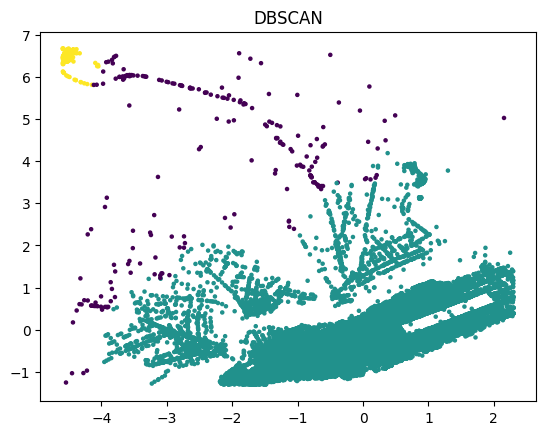

In [ ]:
import matplotlib.pyplot as plt

db = DBSCAN(eps=0.4, min_samples=50)

df_sample['cluster'] = db.fit_predict(X_scaled)

labels = df_sample['cluster'].values
mask = labels != -1

if len(set(labels[mask])) > 1:
    score = silhouette_score(X_scaled[mask], labels[mask])
    print("Final DBSCAN Silhouette Score:", score)
else:
    print("Final DBSCAN Silhouette Score: Not valid")

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=df_sample['cluster'],
    cmap='viridis',
    s=5
)

plt.title("DBSCAN")
plt.show()

### KMeans Clustering — Elbow Method

Apply **KMeans clustering** to pickup coordinates. The **Elbow Method** is used to determine the optimal number of clusters `k` by plotting inertia (within-cluster sum of squares) against values of `k` from 2 to 11.

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

features = ['pickup_latitude', 'pickup_longitude']
X = df_sample[features].copy()

# Remove bad rows
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
X = X.reset_index(drop=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

silhouette_scores = []
inertia = []

for k in range(2, 12):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K = {k}: {score:.4f}")


kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)
score = silhouette_score(X_scaled, labels)
print(f"Silhouette Score for K=5: {score:.4f}")

plt.plot(range(2, 12), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

KeyboardInterrupt: 

### KMeans — Final Clustering with K=5

Based on the elbow plot, **K=5** is selected as the optimal number of clusters. The cluster centres (marked with ✕) represent dominant pickup zones in New York City.

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
df_sample['cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10,8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

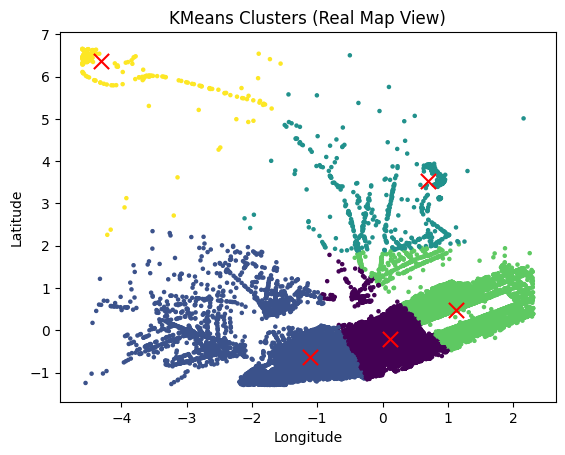

In [ ]:
plt.scatter(
    df_sample['pickup_latitude'],
    df_sample['pickup_longitude'],
    c=df_sample['cluster'],
    s=5
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    marker = 'x',
    color = 'red',
    s = 120
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("KMeans Clusters (Real Map View)")
plt.show()

### Apply Clusters to Full Dataset

Predict cluster assignments for the **full dataset** using the trained KMeans model and inspect the distribution of records per cluster.

In [ ]:
df['cluster'] = kmeans.predict(
    scaler.transform(df[features])
)

print(df['cluster'].value_counts())

cluster
0    604295
1    389440
3    341212
2     43025
4      9707
Name: count, dtype: int64


---

## Summary

| Step | Description | Key Result |
|---|---|---|
| **Data Loading** | Loaded 1,458,644 taxi trips | 11 raw features |
| **Outlier Removal** | Dropped trips > 4 hours | Reduced extreme durations |
| **Trip Classification** | Labelled cancellations, idle, round trips | 4 trip types |
| **Geographic Filter** | Constrained to NYC bounding box | Removed GPS errors |
| **Weather Integration** | Merged weather dataset | Low correlation → excluded |
| **XGBoost Regression** | Predicted log trip duration | **RMSE ≈ 314 seconds** |
| **DBSCAN Clustering** | Density-based spatial clustering | Identified dense zones + noise, SS = 0.815|
| **KMeans Clustering** | K=5 spatial pickup clusters | 4 distinct NYC pickup regions, SS = 0.438 |